In [668]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Prediction Oil Temperature with ETTh1 dataset

### Import

In [669]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

### Read dataset

In [670]:
# Đọc dữ liệu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv("/content/drive/MyDrive/Deep Learning/DL_dataa/data/ETTm1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

target_col = 'OT'

data = df.values

### MSE Loss

In [671]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

### Information

In [672]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69680 entries, 2016-07-01 00:00:00 to 2018-06-26 19:45:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    69680 non-null  float64
 1   HULL    69680 non-null  float64
 2   MUFL    69680 non-null  float64
 3   MULL    69680 non-null  float64
 4   LUFL    69680 non-null  float64
 5   LULL    69680 non-null  float64
 6   OT      69680 non-null  float64
dtypes: float64(7)
memory usage: 4.3 MB


In [673]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


### Thông số

In [674]:
n = len(df)

train_size = int(n * 0.6)
val_size   = int(n * 0.2)
test_size = int(n * 0.2)
print(f'Train size:{train_size}')
lr = 1e-4
weight_decay = 1e-4
drop_out = 0.3

seq_len = 336
pred_len = 24
target_idx = 4

hidden_size = 128
num_layer = 2
epochs = 50

Train size:41808


### Histogram biến mục tiêu

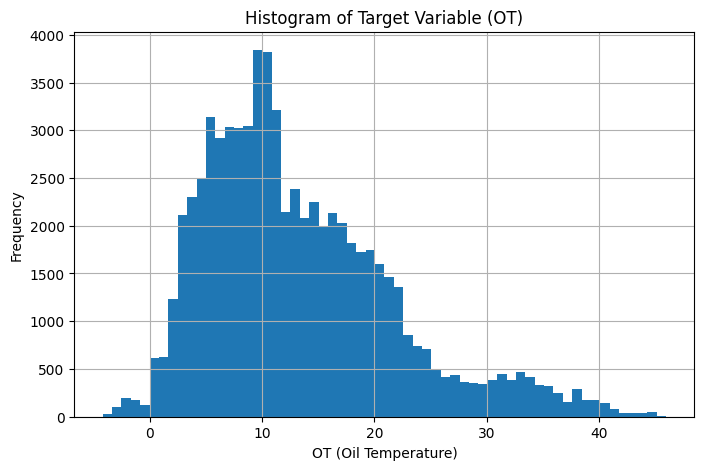

In [675]:
plt.figure(figsize=(8,5))
plt.hist(df["OT"], bins=60)
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Biểu đồ tương quan

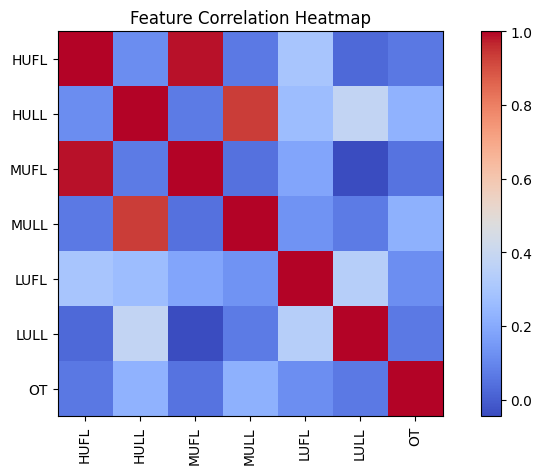

In [676]:
correlation = df.corr()
plt.figure(figsize=(10,5))
plt.imshow(correlation,cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns.tolist())), df.columns.tolist(), rotation=90)
plt.yticks(range(len(df.columns.tolist())), df.columns.tolist())

plt.title("Feature Correlation Heatmap")
plt.show()

In [677]:
# Drop cột MUFL MULL
df.drop(labels=['MUFL','MULL'],axis=1,inplace=True)

In [678]:
df.iloc[120:]

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-02 06:00:00,5.492,3.282,2.985,1.462,20.260000
2016-07-02 06:15:00,5.492,3.014,3.107,1.523,19.134001
2016-07-02 06:30:00,5.559,3.014,3.229,1.553,20.330000
2016-07-02 06:45:00,5.693,3.014,3.076,1.492,20.893000
2016-07-02 07:00:00,5.626,3.215,3.076,1.523,21.104000
...,...,...,...,...,...
2018-06-26 18:45:00,9.310,3.550,3.868,1.462,9.567000
2018-06-26 19:00:00,10.114,3.550,3.716,1.462,9.567000
2018-06-26 19:15:00,10.784,3.349,3.746,1.432,9.426000


### Data augment

In [679]:
stl = STL(df["OT"], period=24)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

df["trend"] = trend
df["seasonal"] = seasonal
df["residual"] = residual



In [680]:
df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433


### Signal plot

plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(df["OT"])
plt.title("Original")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

In [681]:
train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:train_size+val_size]
test_df  = df.iloc[train_size+val_size:]

In [682]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433


### Timer Frezee

In [683]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001,19.217616,0.016692,-0.381308
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000,19.333494,-0.101491,-0.309003
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999,19.457956,-0.041346,-0.352611
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000,19.591195,0.076377,-0.392572
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999,19.733272,0.331343,-0.719616
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000,19.884104,0.074834,-0.472937
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001,20.043653,0.095286,-0.511937
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999,20.212032,0.222403,-0.596436
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999,20.389143,0.113354,-0.383497


In [684]:
# # tổng thay đổi mỗi dòng
# diff_sum_train = train_df.diff().abs().sum(axis=1)
# diff_sum_val = val_df.diff().abs().sum(axis=1)
# diff_sum_test = test_df.diff().abs().sum(axis=1)

# # dòng không thay đổi
# is_constant_train = diff_sum_train == 0
# is_constant_val = diff_sum_val == 0
# is_constant_test = diff_sum_test == 0

# # phát hiện block >= 6 giờ
# window = 6
# freeze_block_train = is_constant_train.rolling(window).sum() >= window
# freeze_block_val = is_constant_val.rolling(window).sum() >= window
# freeze_block_test = is_constant_test.rolling(window).sum() >= window

# train_df.loc[freeze_block_train] = np.nan
# val_df.loc[freeze_block_val] = np.nan
# test_df.loc[freeze_block_test] = np.nan

# train_df.interpolate(method="time", inplace=True)
# val_df.interpolate(method="time", inplace=True)
# test_df.interpolate(method="time", inplace=True)

In [685]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001,19.217616,0.016692,-0.381308
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000,19.333494,-0.101491,-0.309003
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999,19.457956,-0.041346,-0.352611
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000,19.591195,0.076377,-0.392572
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999,19.733272,0.331343,-0.719616
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000,19.884104,0.074834,-0.472937
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001,20.043653,0.095286,-0.511937
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999,20.212032,0.222403,-0.596436
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999,20.389143,0.113354,-0.383497


### Data Augment

In [686]:
def add_time_features(df):
    t = df.index.hour * 4 + df.index.minute // 15
    df["time_sin"] = np.sin(2*np.pi*t/96)
    df["time_cos"] = np.cos(2*np.pi*t/96)
    return df
train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)

/tmp/ipykernel_1079/1165478958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_sin"] = np.sin(2*np.pi*t/96)
/tmp/ipykernel_1079/1165478958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_cos"] = np.cos(2*np.pi*t/96)
/tmp/ipykernel_1079/1165478958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [687]:
# #Train
# train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
# train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)

# #Val
# val_df["hour_sin"] = np.sin(2*np.pi*val_df.index.hour/24)
# val_df["hour_cos"] = np.cos(2*np.pi*val_df.index.hour/24)

# #Test
# test_df["hour_sin"] = np.sin(2*np.pi*test_df.index.hour/24)
# test_df["hour_cos"] = np.cos(2*np.pi*test_df.index.hour/24)

In [688]:
df.head(10)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433
2016-07-01 01:15:00,5.492,1.942,4.112,1.279,27.716999,24.567836,1.019495,2.129668
2016-07-01 01:30:00,5.358,1.875,3.929,1.340,27.646000,24.530228,1.021553,2.094219
2016-07-01 01:45:00,5.157,1.808,3.807,1.279,27.084000,24.491324,1.098168,1.494508
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,24.450770,0.596032,2.740199


### Thống kê phân phối theo tập trước khi scale

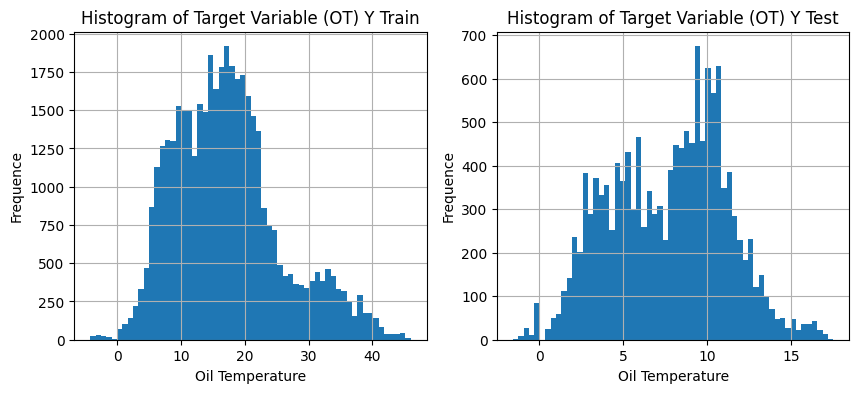

In [689]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([train_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Train')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.subplot(1,2,2)
plt.hist([test_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Test')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.show()

In [690]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

### Inverst Function

In [691]:
def inverst(x,scaler,target_index):
    return x * scaler.scale_[target_index] + scaler.mean_[target_index]

In [692]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, target_index):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_index = target_index

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len, self.target_index]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [693]:

target_index = df.columns.get_loc(target_col)
print(target_index)
train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len, target_index)
val_dataset   = TimeSeriesDataset(val_scaled, seq_len, pred_len, target_index)
test_dataset  = TimeSeriesDataset(test_scaled, seq_len, pred_len, target_index)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

4


### Thống kê phân phối dữ liệu sau khi scale

In [694]:
y_train_all = []
y_test_all = []

for i in range(len(train_dataset)):
    _, y = train_dataset[i]
    y_train_all.append(y.numpy())

for i in range(len(test_dataset)):
    _, y = test_dataset[i]
    y_test_all.append(y.numpy())

y_train_all = np.concatenate(y_train_all)
y_test_all = np.concatenate(y_test_all)

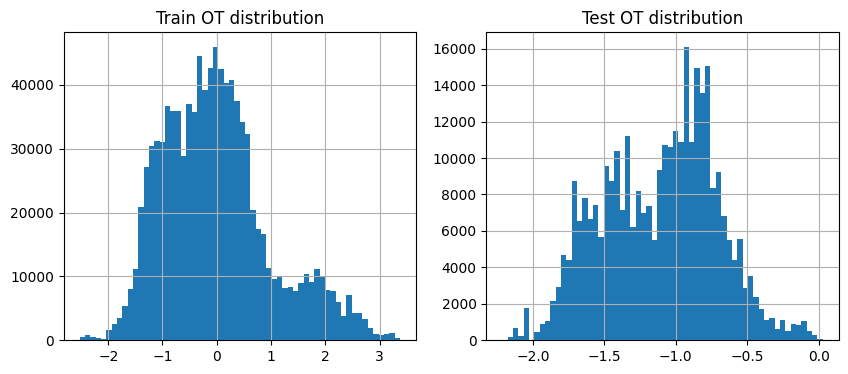

In [695]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train_all, bins=60)
plt.title("Train OT distribution")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y_test_all, bins=60)
plt.title("Test OT distribution")
plt.grid(True)
plt.show()

## Seq2SeqLSTM Model

In [696]:
# class Encoder(nn.Module):
#     def __init__(self, input_dim, hidden_size, num_layers, drop_out):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True,
#             bidirectional=True
#         )

#     def forward(self, x):
#         outputs, (hidden, cell) = self.lstm(x)

#         batch_size = x.size(0)

#         hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
#         cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)

#         hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
#         cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

#         return outputs, hidden, cell
# class Decoder(nn.Module):
#     def __init__(self, hidden_size, num_layers, drop_out):
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=1,
#             hidden_size=hidden_size * 2,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True
#         )

#         self.fc = nn.Sequential(
#             nn.Linear(hidden_size * 2, 128),
#             nn.ReLU(),
#             nn.Dropout(drop_out),
#             nn.Linear(128, 1)
#         )

#     def forward(self, decoder_input, hidden, cell):
#         out, (hidden, cell) = self.lstm(decoder_input, (hidden, cell))
#         out = out.squeeze(1)
#         pred = self.fc(out)
#         return pred, hidden, cell

# class Seq2SeqLSTM(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         hidden_size=128,
#         num_layers=2,
#         pred_len=24,
#         drop_out=0.2,
#         teacher_forcing_ratio=0.2,
#         target_idx=0
#     ):
#         super().__init__()

#         self.encoder = Encoder(input_dim, hidden_size, num_layers, drop_out)
#         self.decoder = Decoder(hidden_size, num_layers, drop_out)

#         self.pred_len = pred_len
#         self.teacher_forcing_ratio = teacher_forcing_ratio
#         self.target_idx = target_idx

#     def forward(self, x, y=None):
#         batch_size = x.size(0)

#         _, hidden, cell = self.encoder(x)

#         decoder_input = x[:, -1:, self.target_idx:self.target_idx+1]

#         outputs = []

#         for t in range(self.pred_len):
#             pred, hidden, cell = self.decoder(decoder_input, hidden, cell)

#             outputs.append(pred.unsqueeze(1))

#             if self.training and y is not None and torch.rand(1).item() < self.teacher_forcing_ratio:
#                 if y.dim() == 2:
#                     decoder_input = y[:, t].unsqueeze(1).unsqueeze(2)
#                 else:
#                     decoder_input = y[:, t:t+1, :]
#             else:
#                 decoder_input = pred.unsqueeze(1)

#         outputs = torch.cat(outputs, dim=1)

#         return outputs.squeeze(-1)

In [697]:
print(train_scaled.shape)

(41808, 10)


In [698]:
# model = Seq2SeqLSTM(
#     input_dim=train_scaled.shape[1],
#     hidden_size=hidden_size,
#     num_layers=num_layer,
#     pred_len=pred_len,
#     drop_out=drop_out,
#     teacher_forcing_ratio=0.2,
#     target_idx=target_idx
# ).to(device)
# criterion = nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode = 'min',
#     patience = 3,
#     factor = 0.5
# )


In [699]:
# history = []
# best_val_loss = float('inf')
# train_loss = float('inf')
# best_epoch = 0
# patience = 5
# counter = 0
# for epoch in range(epochs):

#     model.train()
#     total_train_loss = []

#     for X_batch, y_batch in train_loader:
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()

#         output = model(X_batch)
#         loss = criterion(output,y_batch)

#         loss.backward() # Backpropagation Through Time

#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

#         optimizer.step() # Gradient Descent update
#         y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#         y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
#         loss_real = mse_loss(y_train_pred,y_train_true)
#         total_train_loss.append(loss_real)


#     # ===== VALIDATION =====
#     model.eval()
#     total_val_loss = []

#     with torch.no_grad():
#         for X_val_batch,y_val_batch in val_loader:
#             X_val_batch = X_val_batch.to(device)
#             y_val_batch = y_val_batch.to(device)
#             output = model(X_val_batch)
#             y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
#             y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#             loss = mse_loss(y_val_pred,y_val_true)
#             total_val_loss.append(loss)
#     total_train_loss = np.average(total_train_loss)
#     total_val_loss = np.average(total_val_loss)
#     scheduler_reduce.step(total_val_loss)
#     current_lr = optimizer.param_groups[0]['lr']
#     print(
#         f"Epoch {epoch+1:02d} | "
#         f"Train Loss: {total_train_loss:.4f} | "
#         f"Val Loss: {total_val_loss:.4f} |"
#         f"LR: {current_lr:.6f}"
#     )
#     # ===== SAVE BEST MODEL =====
#     if total_val_loss < best_val_loss:
#         train_loss = total_train_loss
#         best_val_loss = total_val_loss
#         best_epoch = epoch + 1
#         torch.save({
#             'epoch': best_epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_loss': total_val_loss,
#             'train_loss': total_train_loss,
#             'lr':lr,
#             'drop_out':drop_out,
#             'seq_len':seq_len,
#             'pred_len':pred_len
#         }, "seq2seq_checkpoint.pth")
#         counter = 0
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping")
#             break
#     history.append((total_train_loss,total_val_loss))

In [700]:
# print(f'Best Epoch:{best_epoch}')
# print(f'Train Loss: {train_loss}')
# print(f'Val Loss: {best_val_loss}')

In [701]:
# checkpoint = torch.load("G:\\Code\\Deep Learning\\deeplearning\\seq2seqs_checkpoint.pth", map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()
# total_loss=  []
# preds = []
# trues = []

# with torch.no_grad():
#     for x, y in test_loader:
#         x = x.to(device)
#         y = y.to(device)
#         output = model(x)
#         y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
#         y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#         loss = mse_loss(y_val_pred,y_val_true)
#         total_loss.append(loss)
#         preds.append(output.cpu().numpy())
#         trues.append(y.cpu().numpy())
#     total_loss = np.average(total_loss)
# print(f'Loss: {total_loss}')
# preds = np.concatenate(preds, axis=0)
# trues = np.concatenate(trues, axis=0)



In [702]:
# print(preds.shape)
# print(trues.shape)

preds_flat = preds.reshape(-1,1)
trues_flat = trues.reshape(-1,1)

dummy_pred = np.zeros((preds_flat.shape[0], train_scaled.shape[1]))
dummy_true = np.zeros((trues_flat.shape[0], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds_flat[:,0]
dummy_true[:, target_index] = trues_flat[:,0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [703]:

# # tạo mảng giả để inverse
# dummy_pred = np.zeros((preds.shape[1], train_scaled.shape[1]))
# dummy_true = np.zeros((trues.shape[1], train_scaled.shape[1]))

# dummy_pred[:, target_index] = preds[0]
# dummy_true[:, target_index] = trues[0]

# inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
# inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

# MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [704]:
# print(f'Prediction: {inv_pred}')
# print(f'True: {inv_true}')
# print(f'Real Loss: {MSE_Real}')

In [705]:
# plt.figure(figsize=(12,5))
# plt.plot(inv_true[:], label="True")
# plt.plot(inv_pred[:], label="Pred")
# plt.legend()
# plt.show()

## Seq2SeqLSTM + Temporal Attention Model

In [706]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, H, h_t):
        h_t = h_t.unsqueeze(1).repeat(1, H.size(1), 1)

        score = torch.tanh(self.W1(H) + self.W2(h_t))

        # scale (quan trọng)
        score = self.V(score).squeeze(-1) / math.sqrt(H.size(-1))

        weights = torch.softmax(score, dim=1)

        context = torch.sum(weights.unsqueeze(-1) * H, dim=1)

        return context, weights


class LSTM_Attention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, horizon):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=drop_out   # regularization
        )

        self.attention = TemporalAttention(hidden_dim)
        # MLP head mạnh hơn
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(hidden_dim, horizon)
        )
    def forward(self, x):
        H, (h_n, _) = self.lstm(x)

        h_t = h_n[-1]

        context, weights = self.attention(H, h_t)

        combined = torch.cat([h_t, context], dim=1)

        out = self.fc(combined)

        return out

In [707]:
attention_model = LSTM_Attention(
    input_dim = train_scaled.shape[1],
    hidden_dim = hidden_size,
    num_layers = num_layer,
    horizon = pred_len
).to(device)
atm_criterion = nn.MSELoss()
atm_optimizer = torch.optim.AdamW(attention_model.parameters(), lr=lr)
atm_scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    atm_optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)
attention_history = []
attention_best_epoch = 0
attention_best_val_loss = float('inf')
attention_train_loss = float('inf')

### Train Fuction + Predict Function

In [708]:
def running_train(model, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, history, best_epoch, best_val_loss, train_loss,file):
    patience = 5
    counter = 0
    for epoch in range(epochs):

        model.train()
        total_train_loss = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)
            loss = criterion(output,y_batch)

            loss.backward() # Backpropagation Through Time

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

            optimizer.step() # Gradient Descent update
            y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
            y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
            loss_real = mse_loss(y_train_pred,y_train_true)
            total_train_loss.append(loss_real)


        # ===== VALIDATION =====
        model.eval()
        total_val_loss = []

        with torch.no_grad():
            for X_val_batch,y_val_batch in val_loader:
                X_val_batch = X_val_batch.to(device)
                y_val_batch = y_val_batch.to(device)
                output = model(X_val_batch)
                y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
                y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
                loss = mse_loss(y_val_pred,y_val_true)
                total_val_loss.append(loss)
        total_train_loss = np.average(total_train_loss)
        total_val_loss = np.average(total_val_loss)
        scheduler_reduce.step(total_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {total_train_loss:.4f} | "
            f"Val Loss: {total_val_loss:.4f} |"
            f"LR: {current_lr:.6f}"
        )
        # ===== SAVE BEST MODEL =====
        if total_val_loss < best_val_loss:
            train_loss = total_train_loss
            best_val_loss = total_val_loss
            best_epoch = epoch + 1
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': total_val_loss,
                'train_loss': total_train_loss,
                'lr':lr,
                'drop_out':drop_out,
                'seq_len':seq_len,
                'pred_len':pred_len
            }, file)
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break
        history.append((total_train_loss,total_val_loss))
    return best_epoch, best_val_loss, train_loss,history

In [709]:
def predict_running(model,data_loader,file):
  checkpoint = torch.load(file, map_location=device, weights_only=False)
  model.load_state_dict(checkpoint['model_state_dict'])
  model.eval()
  total_loss = []
  preds,trues = [],[]
  with torch.no_grad():
      for x, y in test_loader:
          x = x.to(device)
          y = y.to(device)
          output = model(x)
          y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
          y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
          loss = mse_loss(y_val_pred,y_val_true)
          total_loss.append(loss)
          preds.append(y_val_pred)
          trues.append(y_val_true)
      total_loss = np.average(total_loss)
  print(f'Loss: {total_loss}')
  preds = np.concatenate(preds, axis=0)
  trues = np.concatenate(trues, axis=0)
  print(f'Trues:{trues[0]}')
  print(f'Predict:{preds[0]}')
  return preds,trues,total_loss

### Train LSTM + Attention

In [710]:
attention_best_epoch,attention_best_val_loss,attention_train_loss,attention_history = running_train(
    attention_model,
    train_loader,
    val_loader,
    atm_optimizer,
    atm_criterion,
    atm_scheduler_reduce,
    device,
    epochs,
    attention_history,
    attention_best_epoch,
    attention_best_val_loss,
    attention_train_loss,
    'atm_checkpoint.pth'
)

Epoch 01 | Train Loss: 9.0573 | Val Loss: 1.0809 |LR: 0.000100
Epoch 02 | Train Loss: 2.9565 | Val Loss: 0.9638 |LR: 0.000100
Epoch 03 | Train Loss: 2.3206 | Val Loss: 0.7297 |LR: 0.000100
Epoch 04 | Train Loss: 2.0750 | Val Loss: 0.8625 |LR: 0.000100
Epoch 05 | Train Loss: 1.9037 | Val Loss: 0.8127 |LR: 0.000100
Epoch 06 | Train Loss: 1.8337 | Val Loss: 0.8861 |LR: 0.000100
Epoch 07 | Train Loss: 1.7545 | Val Loss: 0.6188 |LR: 0.000100
Epoch 08 | Train Loss: 1.7100 | Val Loss: 1.1598 |LR: 0.000100
Epoch 09 | Train Loss: 1.6706 | Val Loss: 0.6298 |LR: 0.000100
Epoch 10 | Train Loss: 1.6321 | Val Loss: 0.6474 |LR: 0.000100
Epoch 11 | Train Loss: 1.6163 | Val Loss: 0.6579 |LR: 0.000050
Epoch 12 | Train Loss: 1.5562 | Val Loss: 0.5900 |LR: 0.000050
Epoch 13 | Train Loss: 1.5360 | Val Loss: 0.6352 |LR: 0.000050
Epoch 14 | Train Loss: 1.5417 | Val Loss: 0.6246 |LR: 0.000050
Epoch 15 | Train Loss: 1.5198 | Val Loss: 0.6614 |LR: 0.000050
Epoch 16 | Train Loss: 1.5315 | Val Loss: 0.6930 |LR: 0

In [711]:
print(f'Best Epoch:{attention_best_epoch}')
print(f'Train Loss: {attention_train_loss}')
print(f'Val Loss: {attention_best_val_loss}')

Best Epoch:12
Train Loss: 1.5562219999647706
Val Loss: 0.5900450400521987


### Predict LSTM + Attention Model

In [712]:
atm_preds,atm_trues,atm_total_loss = predict_running(attention_model,test_loader,'/content/atm_checkpoint.pth')

Loss: 0.47602983651348635
Trues:[3.09499987 3.44699971 3.65799975 3.51699995 3.58800053 3.09499987
 3.09499987 2.88399984 2.88399984 2.95500042 3.09499987 3.09499987
 3.02499964 3.23599968 3.51699995 3.79899955 3.58800053 3.72799998
 3.79899955 3.79899955 3.44699971 3.79899955 3.65799975 3.16599944]
Predict:[3.61705028 3.58656189 3.56261129 3.49748803 3.4819004  3.44105442
 3.40814835 3.39575962 3.39344339 3.39828281 3.44451811 3.41697599
 3.44761251 3.51186427 3.60547726 3.71780472 3.78389385 3.86989665
 3.93673553 4.05331399 4.13932085 4.1986784  4.24584405 4.30162935]


### Plot Predict

In [713]:
def plot_function (preds,trues,total_loss,idx,criterion):
  MSE_Loss = criterion(torch.tensor(preds[idx]),torch.tensor(trues[idx]))
  print(f'Total Loss: {total_loss}')
  print(f'Sample {idx} Loss: {MSE_Loss}')
  plt.figure(figsize=(12,5))
  plt.plot(trues[idx], label="True")
  plt.plot(preds[idx], label="Pred")
  plt.title('Predict Plot')
  plt.legend()
  plt.show()

Total Loss: 0.47602983651348635
Sample 10 Loss: 2.0561655065738957


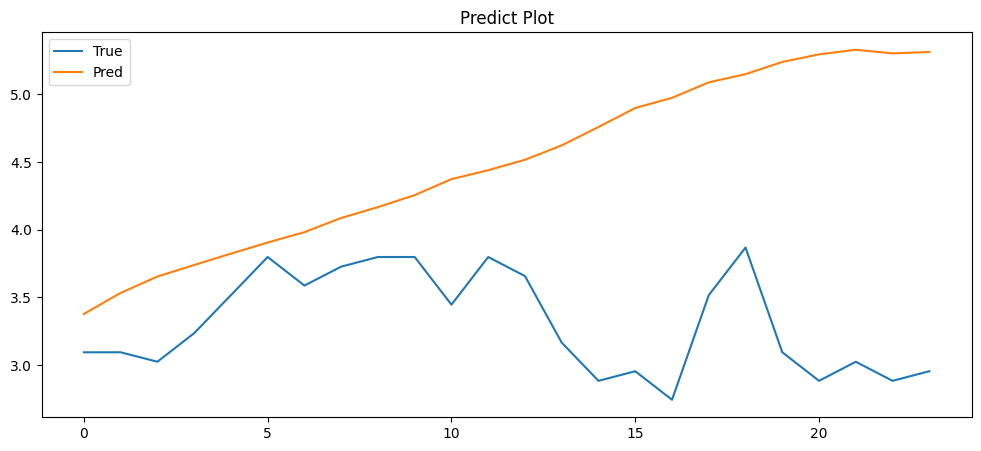

In [714]:
plot_function(atm_preds,atm_trues,atm_total_loss,10,atm_criterion)

## TCN Bilateral Model

In [715]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) \
            if in_channels != out_channels else None

    def forward(self, x):
        # x: (batch, channels, seq_len)

        out = self.conv1(x)
        out = out[:, :, :x.size(2)]  # causal cut
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out[:, :, :x.size(2)]
        out = self.relu(out)
        out = self.dropout(out)

        res = x if self.downsample is None else self.downsample(x)

        return self.relu(out + res)
class TCN(nn.Module):
    def __init__(
        self,
        input_dim,
        num_channels,
        kernel_size=3,
        dropout=0.2,
        horizon=24
    ):
        super().__init__()

        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation = 2 ** i

            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]

            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation,
                    dropout
                )
            )

        self.network = nn.Sequential(*layers)

        self.fc = nn.Linear(num_channels[-1], horizon)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)

        x = x.permute(0, 2, 1)  # -> (batch, input_dim, seq_len)

        y = self.network(x)

        # lấy timestep cuối
        y = y[:, :, -1]

        out = self.fc(y)

        return out

In [716]:
TCN_model = TCN(
    input_dim=train_scaled.shape[1],
    num_channels=[64, 128, 128, 256],
    kernel_size=3,
    dropout=0.2,
    horizon=pred_len
).to(device)
TCN_criterion = nn.MSELoss()
TCN_optimizer = torch.optim.AdamW(TCN_model.parameters(),lr = lr)
TCN_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    TCN_optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)
TCN_history = []
TCN_best_epoch = 0
TCN_best_val_loss = float('inf')
TCN_best_train_loss = float('inf')

In [717]:
TCN_best_epoch,TCN_best_val_loss,TCN_best_train_loss,TCN_history = running_train(
  TCN_model,
  train_loader, val_loader,
  TCN_optimizer, TCN_criterion, TCN_scheduler,
  device,
  epochs,
  TCN_history, TCN_best_epoch, TCN_best_val_loss, TCN_best_train_loss,
  'TCN_checkpoint.pth'
)

Epoch 01 | Train Loss: 4.6093 | Val Loss: 1.8292 |LR: 0.000100
Epoch 02 | Train Loss: 1.3330 | Val Loss: 0.7779 |LR: 0.000100
Epoch 03 | Train Loss: 1.0498 | Val Loss: 0.6784 |LR: 0.000100
Epoch 04 | Train Loss: 0.8929 | Val Loss: 0.7490 |LR: 0.000100
Epoch 05 | Train Loss: 0.7875 | Val Loss: 0.5632 |LR: 0.000100
Epoch 06 | Train Loss: 0.7048 | Val Loss: 0.8464 |LR: 0.000100
Epoch 07 | Train Loss: 0.6458 | Val Loss: 0.7502 |LR: 0.000100
Epoch 08 | Train Loss: 0.6030 | Val Loss: 0.5513 |LR: 0.000100
Epoch 09 | Train Loss: 0.5626 | Val Loss: 0.6527 |LR: 0.000100
Epoch 10 | Train Loss: 0.5310 | Val Loss: 0.8184 |LR: 0.000100
Epoch 11 | Train Loss: 0.5078 | Val Loss: 0.7288 |LR: 0.000100
Epoch 12 | Train Loss: 0.4797 | Val Loss: 0.4362 |LR: 0.000100
Epoch 13 | Train Loss: 0.4617 | Val Loss: 0.6275 |LR: 0.000100
Epoch 14 | Train Loss: 0.4417 | Val Loss: 0.5512 |LR: 0.000100
Epoch 15 | Train Loss: 0.4233 | Val Loss: 0.5468 |LR: 0.000100
Epoch 16 | Train Loss: 0.4115 | Val Loss: 0.4148 |LR: 0

In [718]:
print(f'TCN Best Epoch: {TCN_best_epoch}')
print(f'TCN Train Loss: {TCN_best_train_loss}')
print(f'TCN Val Loss: {TCN_best_val_loss}')

TCN Best Epoch: 16
TCN Train Loss: 0.41149915476911436
TCN Val Loss: 0.4147835184454572


In [719]:
TCN_preds,TCN_trues,TCN_total_loss = predict_running(TCN_model,test_loader,'/content/TCN_checkpoint.pth')

Loss: 0.36890028374722494
Trues:[3.09499987 3.44699971 3.65799975 3.51699995 3.58800053 3.09499987
 3.09499987 2.88399984 2.88399984 2.95500042 3.09499987 3.09499987
 3.02499964 3.23599968 3.51699995 3.79899955 3.58800053 3.72799998
 3.79899955 3.79899955 3.44699971 3.79899955 3.65799975 3.16599944]
Predict:[3.48944362 3.6326724  3.41056705 3.34867818 3.41980558 3.33314737
 3.13596355 3.09281757 3.04330729 2.95134397 3.02577983 3.16632106
 3.42582798 3.54130463 3.69936823 3.70280656 3.74664953 3.5316207
 3.54514675 3.44498075 3.47038926 3.4830154  3.25684777 3.30857992]


In [723]:
print(f'TCN Predict Loss: {TCN_total_loss}')
print(f'TCN Predict: {TCN_preds}')
print(f'TCN True Grouth: {TCN_trues}')

TCN Predict Loss: 0.36890028374722494
TCN Predict: [[ 3.48944362  3.6326724   3.41056705 ...  3.4830154   3.25684777
   3.30857992]
 [ 3.42447659  3.6767954   3.55292331 ...  3.35751394  3.12933647
   3.15083286]
 [ 3.51117539  3.65366557  3.38811495 ...  3.15191742  2.84194146
   2.85595855]
 ...
 [ 9.93765609 10.21014932 10.16406418 ...  8.82952773  8.75810762
   8.72344434]
 [10.04044116 10.36868976 10.40234103 ...  8.9772449   8.94198353
   8.97886666]
 [10.38397556 10.72958218 10.69663095 ...  9.32688894  9.35336325
   9.31759156]]
TCN True Grouth: [[ 3.09499987  3.44699971  3.65799975 ...  3.79899955  3.65799975
   3.16599944]
 [ 3.44699971  3.65799975  3.51699995 ...  3.65799975  3.16599944
   2.88399984]
 [ 3.65799975  3.51699995  3.58800053 ...  3.16599944  2.88399984
   2.95500042]
 ...
 [ 9.70800042  9.98900018 10.19999971 ...  9.56700062  9.56700062
   9.4259998 ]
 [ 9.98900018 10.19999971 10.55200006 ...  9.56700062  9.4259998
   9.4259998 ]
 [10.19999971 10.55200006 10.69

Total Loss: 0.36890028374722494
Sample 100 Loss: 0.8139932505089211


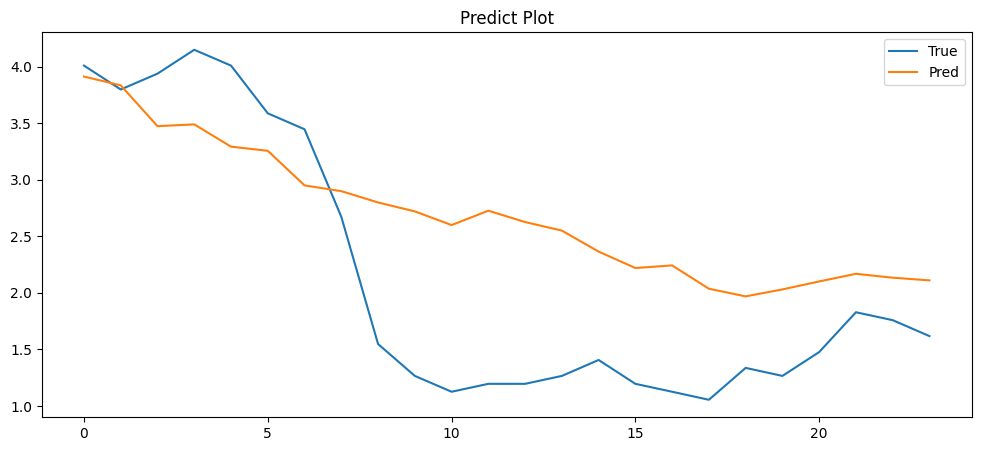

In [727]:
plot_function(TCN_preds,TCN_trues,TCN_total_loss,100,TCN_criterion)